<a href="https://colab.research.google.com/github/Shaikh-Uzair-Ahmed/1BM23CS307/blob/ML/1BM23CS07_LAB3_Logistic_Regression/LogisticRegression_Binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
print("Pandas library imported.")

Pandas library imported.


In [2]:
df_zoo_data = pd.read_csv('/content/zoo-data.csv')
df_zoo_class_type = pd.read_csv('/content/zoo-class-type.csv')

print("First 5 rows of df_zoo_data:")
print(df_zoo_data.head())

print("\nFirst 5 rows of df_zoo_class_type:")
print(df_zoo_class_type.head())

First 5 rows of df_zoo_data:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   class_type  
0           1  
1      

In [3]:
df_merged = pd.merge(df_zoo_data, df_zoo_class_type, left_on='class_type', right_on='Class_Number', how='inner')

# Drop the redundant 'Class_Number' column
df_merged.drop('Class_Number', axis=1, inplace=True)

print("First 5 rows of df_merged after merging and dropping 'Class_Number':")
print(df_merged.head())

print("\nColumns in df_merged:")
print(df_merged.columns)

First 5 rows of df_merged after merging and dropping 'Class_Number':
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  ...  venomous  fins  legs  tail  domestic  catsize  \
0        1         1  ...         0     0     4     0         0        1   
1        1         1  ...         0     0     4     1         0        1   
2        1         1  ...         0     1     0     1         0        0   
3        1         1  ...         0     0     4     0         0        1   
4        1         1  ...         0     0     4     1         0        1   

   class_type  Number_Of_Anim

In [4]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_merged.drop(columns=['animal_name', 'class_type', 'Number_Of_Animal_Species_In_Class', 'Class_Type', 'Animal_Names'])
y = df_merged['class_type']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Data split into training and testing sets.")

Shape of X_train: (70, 16)
Shape of X_test: (31, 16)
Shape of y_train: (70,)
Shape of y_test: (31,)
Data split into training and testing sets.


In [5]:
from sklearn.linear_model import LogisticRegression

# Instantiate the Logistic Regression model
# Set multi_class='multinomial' for multiclass classification
# Set solver='lbfgs' and max_iter=1000 for convergence
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model initialized and trained successfully.")

Logistic Regression model initialized and trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [10]:
from sklearn.metrics import accuracy_score

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy on Test Data: {accuracy:.4f}")

Model Accuracy on Test Data: 0.9355


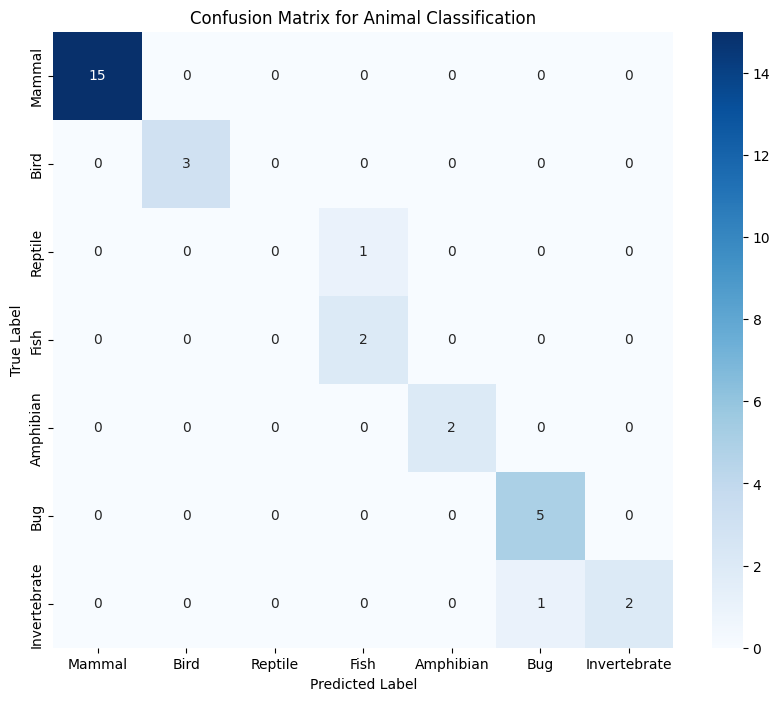

Confusion matrix visualization complete.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class names from df_zoo_class_type for better interpretability
# Map class_type (1-indexed) to Class_Type string
class_names = df_zoo_class_type.set_index('Class_Number')['Class_Type'].loc[sorted(y.unique())].values

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Animal Classification')
plt.show()

print("Confusion matrix visualization complete.")